In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("glass (1).csv")

# Column names add
df.columns = ['RI','Na','Mg','Al','Si','K','Ca','Ba','Fe','Type']

df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [5]:
print(df.shape)
print(df.info())
print(df.describe())


(214, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB
None
               RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.511150   10.730000    0.000000    0.290000   69.81

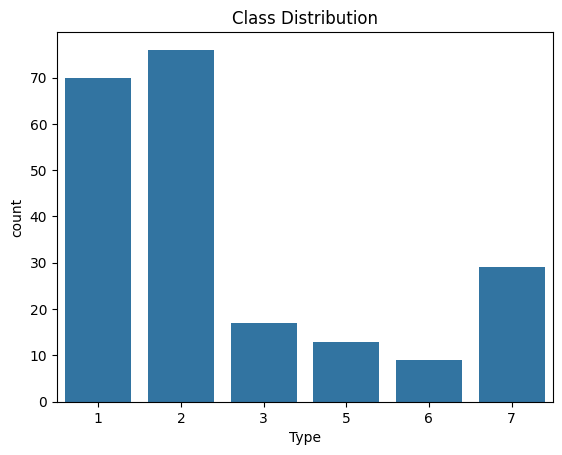

In [6]:
# Class distribution
sns.countplot(x=df['Type'])
plt.title("Class Distribution")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop("Type", axis=1)
y = df["Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#KNN

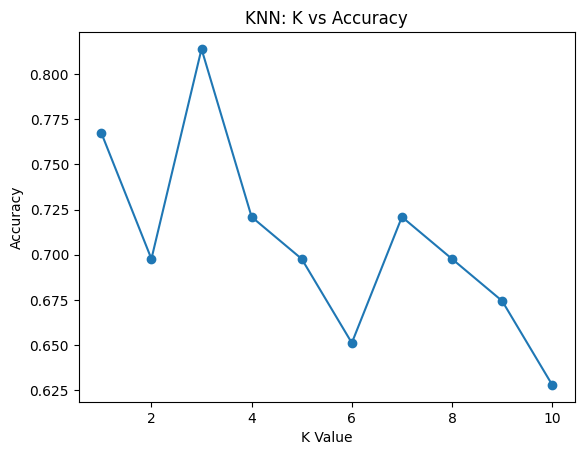

In [15]:
from sklearn.neighbors import KNeighborsClassifier

k_values = range(1, 11)
acc_list = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc_list.append(accuracy_score(y_test, y_pred))

plt.figure()
plt.plot(k_values, acc_list, marker='o')
plt.title("KNN: K vs Accuracy")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.show()

In [17]:
best_k = k_values[np.argmax(acc_list)]
print("Best K:", best_k)

Best K: 3


In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", acc_knn)

KNN Accuracy: 0.813953488372093


#SVM

In [9]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", acc_svm)

SVM Accuracy: 0.7209302325581395


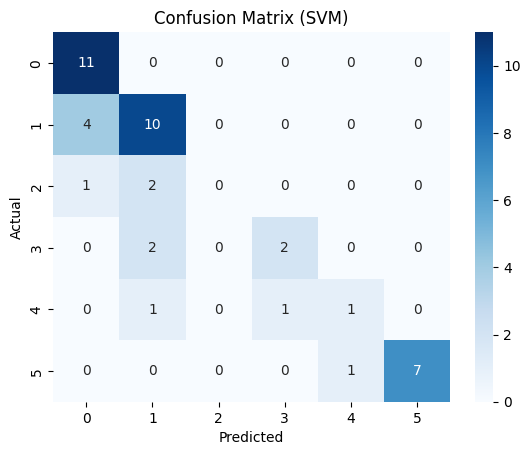

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (SVM)")
plt.show()

#NB

In [10]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)
print("Naive Bayes Accuracy:", acc_nb)

Naive Bayes Accuracy: 0.5581395348837209


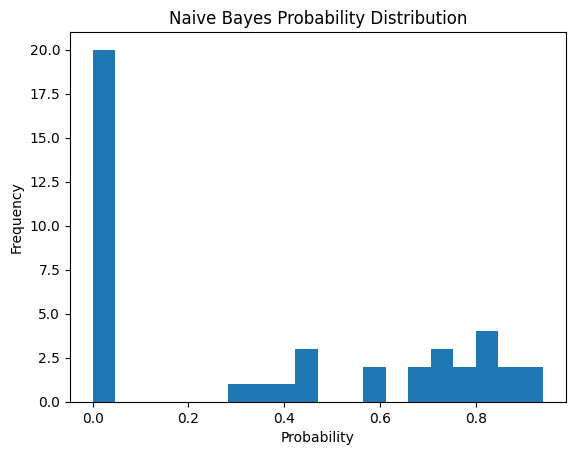

In [20]:
y_prob = nb.predict_proba(X_test)

plt.figure()
plt.hist(y_prob[:,0], bins=20)

plt.title("Naive Bayes Probability Distribution")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()

#Compare

In [22]:
results = pd.DataFrame({
    "Model": ["KNN", "SVM", "Naive Bayes"],
    "Accuracy": [acc_knn, acc_svm, acc_nb]
})

print(results)

         Model  Accuracy
0          KNN  0.813953
1          SVM  0.720930
2  Naive Bayes  0.558140


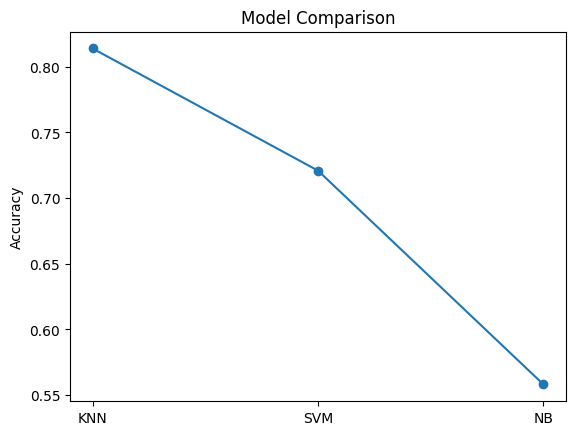

In [24]:
plt.figure()

models = ['KNN', 'SVM', 'NB']
accuracies = [acc_knn, acc_svm, acc_nb]

plt.plot(models, accuracies, marker='o')

plt.title("Model Comparison")
plt.ylabel("Accuracy")

plt.show()

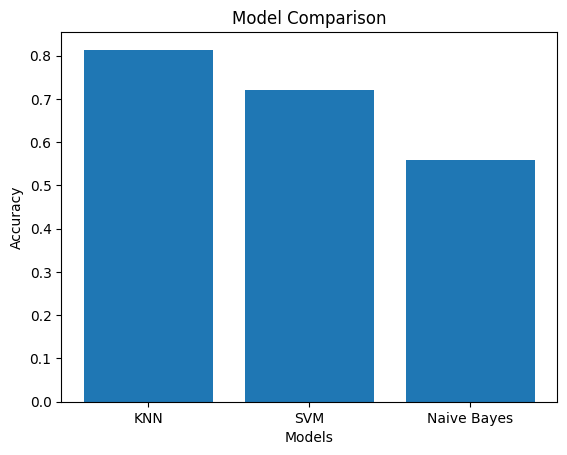

In [25]:
models = ['KNN', 'SVM', 'Naive Bayes']
accuracies = [acc_knn, acc_svm, acc_nb]

plt.figure()
plt.bar(models, accuracies)

plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")

plt.show()